In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sim_wrapper.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [2]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 7.5e9 * 2 * np.pi)
sim.add_param('amp_in', 0.4) # signal amplitude
sim.add_param('kappa', 0.02e9 * 2 * np.pi)  # mode decay rate
sim.add_param('phase_in', 0)
sim.add_paramsweep('phi_DC', -1.5, 2, 200)
sim.add_param('epsilon', 0)
sim.add_param('w_phi', 1e9 * 2 * np.pi)
sim.add_paramsweep('w_in', 4e9*2*np.pi, 8e9*2*np.pi, 100, is_excitation=True) # signal frequency


sim.add_EOM('x1', 'x2')
sim.add_EOM('phi_flux', 'epsilon*w_phi*cos(w_phi*t)', IC=0.25) # does nothing for now
sim.add_EOM('x2', '-kappa*x2 - w_0**2*abs(cos(phi_DC*pi))*sin(x1) + 2*kappa*(-amp_in*w_in*cos(w_in*t + phase_in))')
sim.add_EOM('x3','x2 + amp_in*w_in*cos(w_in*t + phase_in)')

sim.set_solve_type('decimate')

sim.specify_time(20, 400, d_factor=1)

sim.validate()

Simulation validation success!


C:\Users\boris\Documents\GitHub\gpu_odes\sim_wrapper\sim.py:148: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if self.excitation_freq == '':


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


(3000000000.0, 30000000000.0)

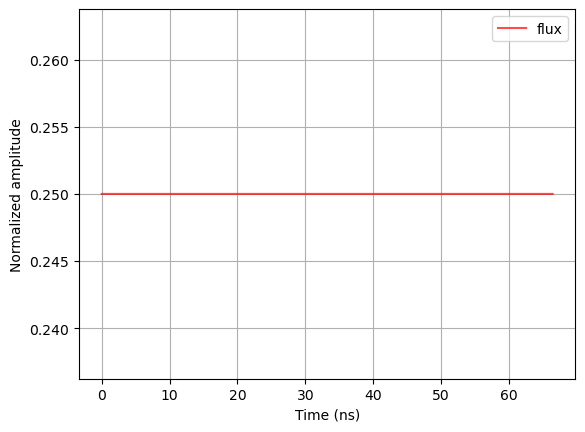

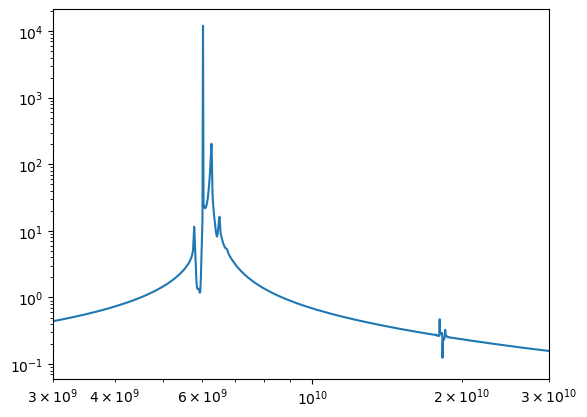

In [3]:
sim.param_dict_nosweep['amp_in'] = 3
sim.param_dict_nosweep['phi_DC'] = 0.25

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())
plt.xlim([3e9, 30e9])



In [4]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:03<00:00, 2126.80it/s]


 
...finished GPU solve!


Drive frequency: 5.575757575757576 GHz


Text(0.5, 1.0, 'Phase with bias current at drive frequency 5.575757575757576 GHz')

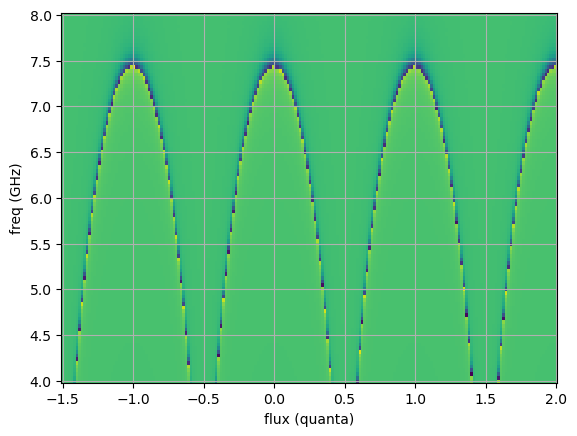

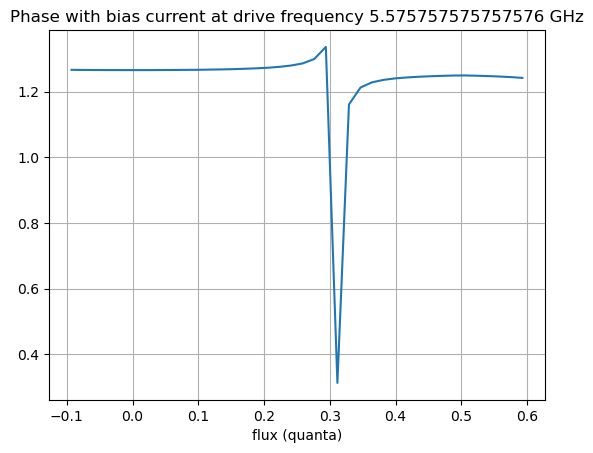

In [5]:
phase = np.angle(1j*Q+I)

plt.pcolor(sim.paramsweep_dict['phi_DC'],sim.paramsweep_dict['w_in']/(1e9*2*np.pi),  phase[3,:,:,-1].transpose())
plt.xlabel('flux (quanta)')
plt.ylabel('freq (GHz)')
plt.grid()

w_in_i = 39

print('Drive frequency: ' + str(sim.paramsweep_dict['w_in'][w_in_i]/(1e9*2*np.pi)) + ' GHz')

plt.figure()
plt.plot(sim.paramsweep_dict['phi_DC'][80:120],  np.unwrap(phase[3,80:120,w_in_i,-1]))
plt.xlabel('flux (quanta)')
plt.grid()
plt.title('Phase with bias current at drive frequency ' + str(sim.paramsweep_dict['w_in'][w_in_i]/(1e9*2*np.pi)) + ' GHz')


In [6]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 7.5e9 * 2 * np.pi)
sim.add_param('amp_in', 0.4) # signal amplitude
sim.add_param('kappa', 0.2e9 * 2 * np.pi)  # mode decay rate
sim.add_param('phase_in', 0)
sim.add_paramsweep('phi_DC', -1.5, 2, 200)
sim.add_param('epsilon', 0)
sim.add_param('w_phi', 1e9 * 2 * np.pi)
sim.add_paramsweep('w_in', 4e9*2*np.pi, 8e9*2*np.pi, 100, is_excitation=True) # signal frequency


sim.add_EOM('x1', 'x2')
sim.add_EOM('phi_flux', 'epsilon*w_phi*cos(w_phi*t)', IC=0.25) # does nothing for now
sim.add_EOM('x2', '-kappa*x2 - w_0**2*abs(cos(phi_flux*pi))*sin(x1) + 2*kappa*(-amp_in*w_in*cos(w_in*t + phase_in))')
sim.add_EOM('x3','x2 + amp_in*w_in*cos(w_in*t + phase_in)')

sim.set_solve_type('decimate')

sim.specify_time(20, 5000, d_factor=1)

sim.validate()

Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


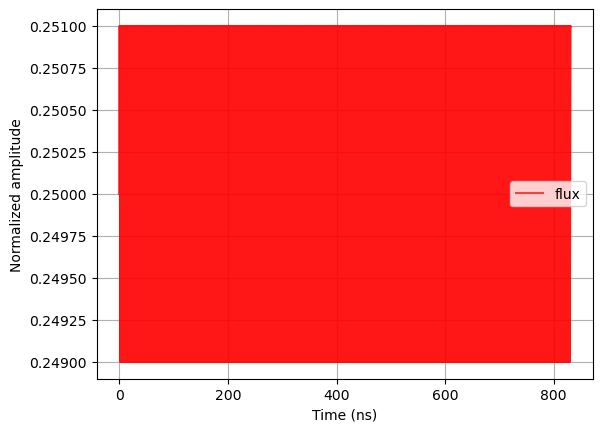

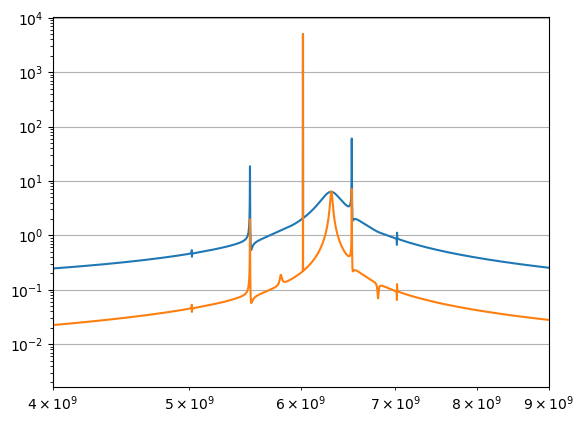

In [7]:
sim.param_dict_nosweep['amp_in'] = 0.1
sim.param_dict_nosweep['phi_DC'] = 0.28
sim.param_dict_nosweep['epsilon'] = 0.001
sim.param_dict_nosweep['w_phi'] = 0.5e9 * 2 * np.pi
sim.param_dict_nosweep['kappa'] = 0.2e9 * 2 * np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())
plt.xlim([4e9, 9e9])
plt.grid()

sim.param_dict_nosweep['kappa'] = 0.02e9 * 2 * np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())



Simulation validation success!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


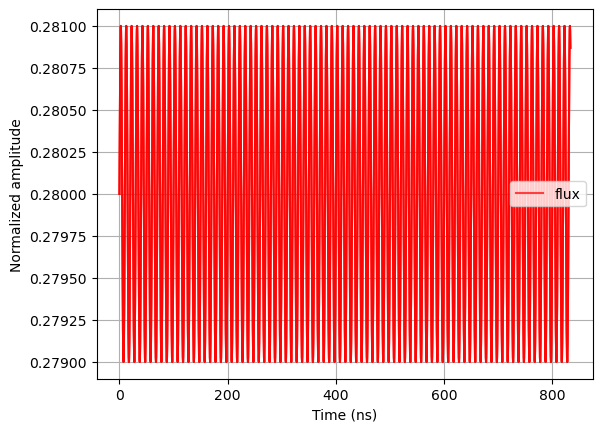

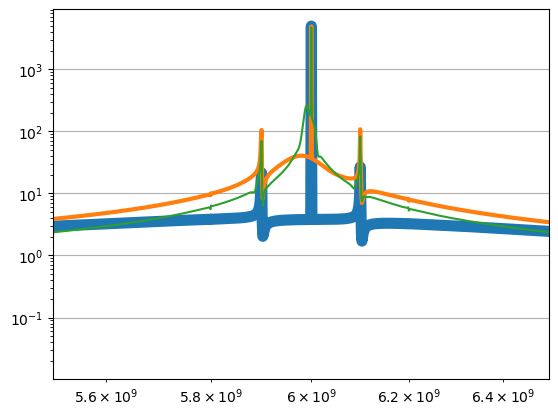

In [8]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 6.0e9 * 2 * np.pi)
sim.add_param('amp_in', 0.4) # signal amplitude
sim.add_param('kappa', 0.1e9 * 2 * np.pi)  # mode decay rate
sim.add_param('phase_in', 0)
sim.add_paramsweep('phi_DC', -1.5, 2, 200)
sim.add_param('epsilon', 0)
sim.add_param('w_phi', 1e9 * 2 * np.pi)
sim.add_paramsweep('w_in', 4e9*2*np.pi, 8e9*2*np.pi, 101, is_excitation=True) # signal frequency


sim.add_EOM('x1', 'x2')
sim.add_EOM('phi_flux', 'epsilon*w_phi*cos(w_phi*t)', IC=0.28) # does nothing for now
sim.add_EOM('x2', '-kappa*x2 - w_0**2*(1 + epsilon*cos(t*w_phi))*sin(x1) + 2*kappa*(amp_in*w_in*cos(w_in*t + phase_in))')
sim.add_EOM('x3','x2 - amp_in*w_in*cos(w_in*t + phase_in)')

sim.set_solve_type('decimate')

sim.specify_time(20, 5000, d_factor=1)

sim.validate()

sim.param_dict_nosweep['amp_in'] = 0.1
sim.param_dict_nosweep['phi_DC'] = 0.28
sim.param_dict_nosweep['epsilon'] = 0.001
sim.param_dict_nosweep['w_phi'] = 0.1e9 * 2 * np.pi
sim.param_dict_nosweep['kappa'] = 1e9 * 2 * np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose(), linewidth=8)
plt.xlim([5.5e9, 6.5e9])
plt.grid()

sim.param_dict_nosweep['kappa'] = 0.1e9 * 2 * np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose(), linewidth=3)

sim.param_dict_nosweep['kappa'] = 0.01e9 * 2 * np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())

Simulation validation success!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


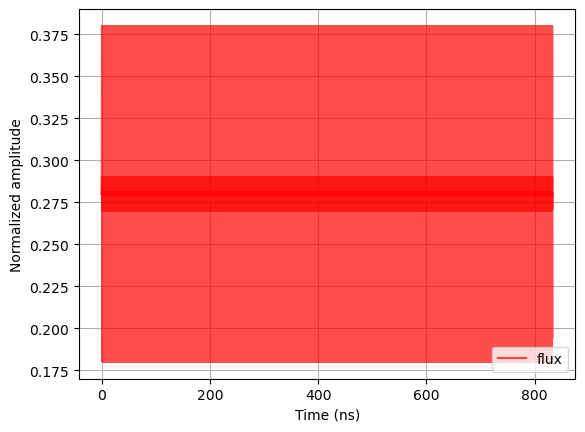

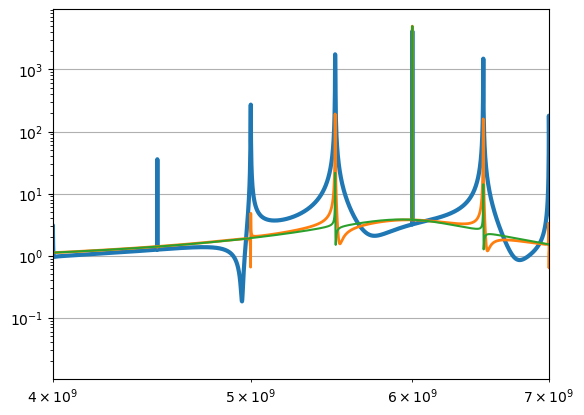

In [140]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 6.0e9 * 2 * np.pi)
sim.add_param('amp_in', 0.4) # signal amplitude
sim.add_param('kappa', 0.1e9 * 2 * np.pi)  # mode decay rate
sim.add_param('phase_in', 0)
sim.add_paramsweep('phi_DC', -1.5, 2, 200)
sim.add_param('epsilon', 0)
sim.add_param('w_phi', 1e9 * 2 * np.pi)
sim.add_paramsweep('w_in', 4e9*2*np.pi, 8e9*2*np.pi, 101, is_excitation=True) # signal frequency


sim.add_EOM('x1', 'x2')
sim.add_EOM('phi_flux', 'epsilon*w_phi*cos(w_phi*t)', IC=0.28) # does nothing for now
sim.add_EOM('x2', '-kappa*x2 - w_0**2*(1 + epsilon*cos(t*w_phi))*sin(x1) + 2*kappa*(amp_in*w_in*cos(w_in*t + phase_in))')
sim.add_EOM('x3','x2 - amp_in*w_in*cos(w_in*t + phase_in)')

sim.set_solve_type('decimate')

sim.specify_time(20, 5000, d_factor=1)

sim.validate()

sim.param_dict_nosweep['amp_in'] = 0.1
sim.param_dict_nosweep['epsilon'] = 0.1
sim.param_dict_nosweep['w_phi'] = 0.5e9 * 2 * np.pi
sim.param_dict_nosweep['kappa'] = 1e9 * 2 * np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose(), linewidth=3)
plt.xlim([4e9, 7e9])
plt.grid()

sim.param_dict_nosweep['epsilon'] = 0.01

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose(), linewidth=2)

sim.param_dict_nosweep['epsilon'] = 0.001

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())

Simulation validation success!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!
Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


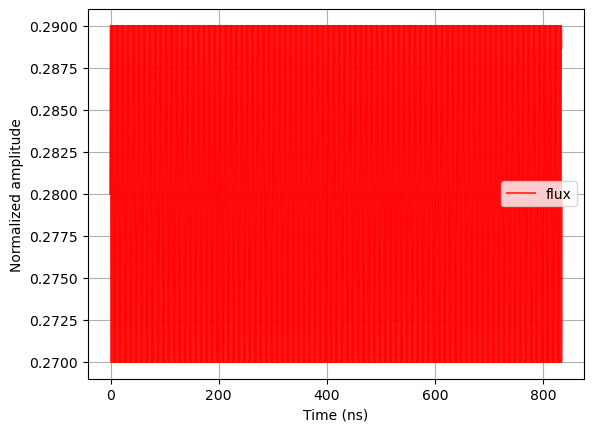

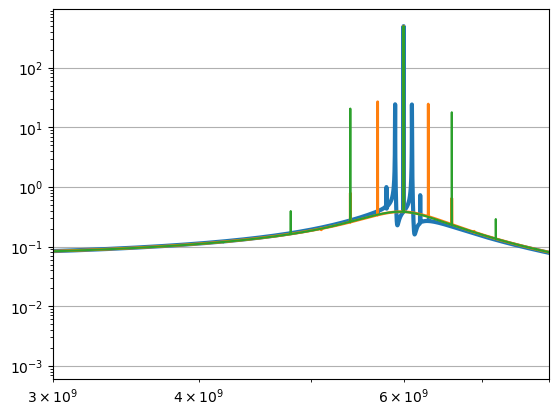

In [111]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 6.0e9 * 2 * np.pi)
sim.add_param('amp_in', 0.4) # signal amplitude
sim.add_param('kappa', 0.1e9 * 2 * np.pi)  # mode decay rate
sim.add_param('phase_in', 0)
sim.add_paramsweep('phi_DC', -1.5, 2, 200)
sim.add_param('epsilon', 0)
sim.add_param('w_phi', 1e9 * 2 * np.pi)
sim.add_paramsweep('w_in', 4e9*2*np.pi, 8e9*2*np.pi, 101, is_excitation=True) # signal frequency


sim.add_EOM('x1', 'x2')
sim.add_EOM('phi_flux', 'epsilon*w_phi*cos(w_phi*t)', IC=0.28) # does nothing for now
sim.add_EOM('x2', '-kappa*x2 - w_0**2*(1 + epsilon*cos(t*w_phi))*sin(x1) + 2*kappa*(amp_in*w_in*cos(w_in*t + phase_in))')
sim.add_EOM('x3','x2 - amp_in*w_in*cos(w_in*t + phase_in)')

sim.set_solve_type('decimate')

sim.specify_time(20, 5000, d_factor=1)

sim.validate()

sim.param_dict_nosweep['amp_in'] = 0.01
sim.param_dict_nosweep['phi_DC'] = 0.28
sim.param_dict_nosweep['epsilon'] = 0.01
sim.param_dict_nosweep['w_phi'] = 0.1e9 * 2 * np.pi
sim.param_dict_nosweep['kappa'] = 1e9 * 2 * np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose(), linewidth=3)
plt.xlim([3e9, 8e9])
plt.grid()

sim.param_dict_nosweep['w_phi'] = 0.3e9 * 2 * np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose(), linewidth=2)

sim.param_dict_nosweep['w_phi'] = 0.6e9 * 2 * np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())

In [110]:
20*np.log10(np.abs(fftx).transpose()[4583]/np.abs(fftx).transpose()[4167])

20.019307324362636